Imports and Loads

In [12]:
import pandas as pd
import matplotlib.pyplot as plt

import numpy as np
from shapely.geometry import Polygon
import geopandas as gpd

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from plots import EventPlot

In [2]:
# loading the dataset 
url = "https://www.ncei.noaa.gov/data/international-best-track-archive-for-climate-stewardship-ibtracs/v04r01/access/csv/ibtracs.ALL.list.v04r01.csv"
df = pd.read_csv(url, skiprows=[1], low_memory=False)

In [6]:
df.head(2)

,SID,SEASON,NUMBER,BASIN,SUBBASIN,NAME,ISO_TIME,NATURE,LAT,LON,...,BOM_GUST_PER,REUNION_GUST,REUNION_GUST_PER,USA_SEAHGT,USA_SEARAD_NE,USA_SEARAD_SE,USA_SEARAD_SW,USA_SEARAD_NW,STORM_SPEED,STORM_DIR
0,1842298N11080,1842,1,NI,BB,UNNAMED,1842-10-25 03:00:00,NR,10.9,80.3,...,,,,,,,,,9,265
1,1842298N11080,1842,1,NI,BB,UNNAMED,1842-10-25 06:00:00,NR,10.9,79.8,...,,,,,,,,,9,265


In [7]:
print(list(df.columns))

['SID', 'SEASON', 'NUMBER', 'BASIN', 'SUBBASIN', 'NAME', 'ISO_TIME', 'NATURE', 'LAT', 'LON', 'WMO_WIND', 'WMO_PRES', 'WMO_AGENCY', 'TRACK_TYPE', 'DIST2LAND', 'LANDFALL', 'IFLAG', 'USA_AGENCY', 'USA_ATCF_ID', 'USA_LAT', 'USA_LON', 'USA_RECORD', 'USA_STATUS', 'USA_WIND', 'USA_PRES', 'USA_SSHS', 'USA_R34_NE', 'USA_R34_SE', 'USA_R34_SW', 'USA_R34_NW', 'USA_R50_NE', 'USA_R50_SE', 'USA_R50_SW', 'USA_R50_NW', 'USA_R64_NE', 'USA_R64_SE', 'USA_R64_SW', 'USA_R64_NW', 'USA_POCI', 'USA_ROCI', 'USA_RMW', 'USA_EYE', 'TOKYO_LAT', 'TOKYO_LON', 'TOKYO_GRADE', 'TOKYO_WIND', 'TOKYO_PRES', 'TOKYO_R50_DIR', 'TOKYO_R50_LONG', 'TOKYO_R50_SHORT', 'TOKYO_R30_DIR', 'TOKYO_R30_LONG', 'TOKYO_R30_SHORT', 'TOKYO_LAND', 'CMA_LAT', 'CMA_LON', 'CMA_CAT', 'CMA_WIND', 'CMA_PRES', 'HKO_LAT', 'HKO_LON', 'HKO_CAT', 'HKO_WIND', 'HKO_PRES', 'KMA_LAT', 'KMA_LON', 'KMA_CAT', 'KMA_WIND', 'KMA_PRES', 'KMA_R50_DIR', 'KMA_R50_LONG', 'KMA_R50_SHORT', 'KMA_R30_DIR', 'KMA_R30_LONG', 'KMA_R30_SHORT', 'NEWDELHI_LAT', 'NEWDELHI_LON', 'N

In [8]:
numeric_conversion_cols = ['LAT', 'LON', 'USA_WIND', 'SEASON']

# convert key columns to numeric (empty strings to nans)
for col in numeric_conversion_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

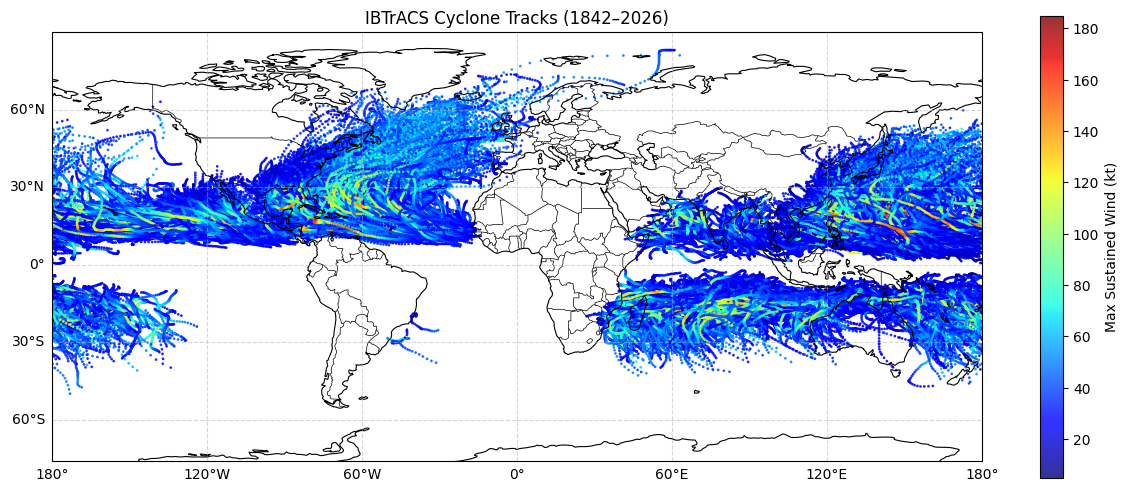

In [9]:
fig = plt.figure(figsize=(15, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Scatter points
sc = ax.scatter(df['LON'], df['LAT'], c=df['USA_WIND'], cmap='jet', s=1, alpha=0.8, transform=ccrs.PlateCarree())

# coastlines and country borders
ax.coastlines(resolution='110m', linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# gridlines lat lon
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.5)
gl.top_labels = False; gl.right_labels = False

plt.colorbar(sc, ax=ax, label='Max Sustained Wind (kt)')
plt.title('IBTrACS Cyclone Tracks (1842–2026)')
plt.show()

a search using storm NAME is a little inefficient, so let's do it based on Event IDs or SID instead. This will allow us to filter the dataframe more efficiently and avoid potential issues with duplicate storm names across different years or basins.

In [10]:
# for example VINCE in Spain. 
VINCE = df[df['NAME'].str.upper() == 'VINCE'].copy()
print(VINCE.groupby('SID').size())

SID
2005281N33339     27
2011009S15113     59
2025031S15106    107
dtype: int64


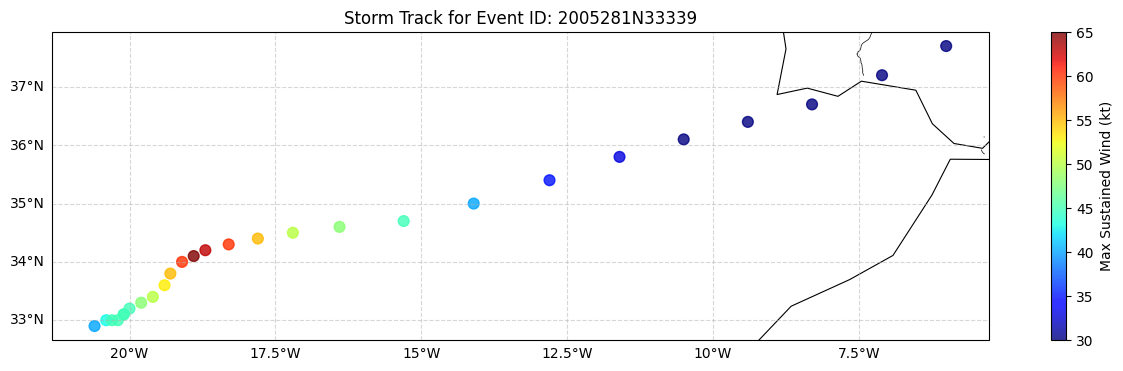

In [13]:
EventPlot(df, '2005281N33339')

In [14]:
storms = ['VINCE', 'AMPHAN', 'MILTON', 'RAGASA']

# search for SIDs for the above storms. 
for name in storms:
    sids = df[df['NAME'].str.upper() == name.upper()]['SID'].dropna().unique()
    print(name, sids)

VINCE ['2005281N33339' '2011009S15113' '2025031S15106']
AMPHAN ['2020136N10088']
MILTON ['2024279N21265']
RAGASA ['2025260N13138']


In [ ]:
# Final events to plot
eventIDs = ['2005281N33339', '2020136N10088', '2024279N21265', '2025260N13138']

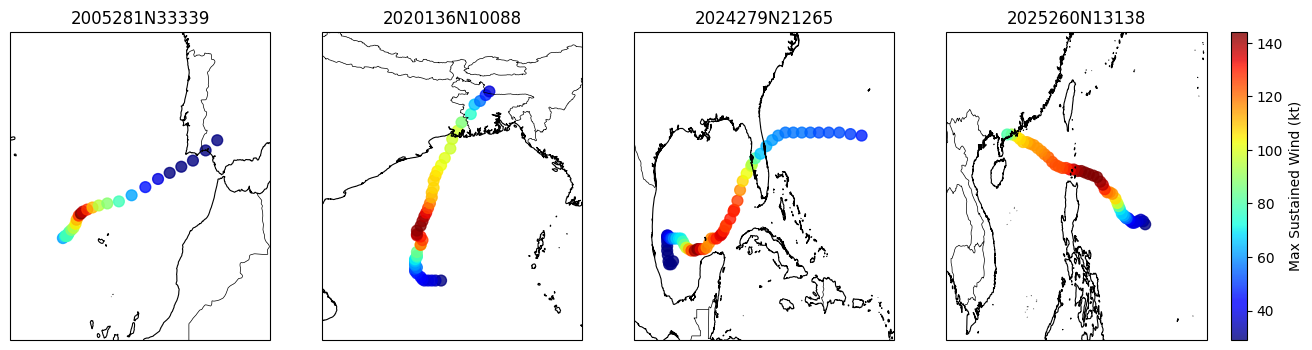

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4), subplot_kw={'projection': ccrs.PlateCarree()})

for ax, name in zip(axes, eventIDs):

    storm = df[df['SID'] == name]

    sc = ax.scatter(storm['LON'], storm['LAT'], c=storm['USA_WIND'], cmap='jet', s=60, alpha=0.8, transform=ccrs.PlateCarree())

    # Coastlines
    ax.coastlines(resolution='10m', linewidth=0.8) ; ax.add_feature(cfeature.BORDERS, linewidth=0.5)

    # Zoom to storm extent with padding
    if len(storm) > 0:
        pad = 5
        ax.set_extent([
            storm['LON'].min() - pad,
            storm['LON'].max() + pad,
            storm['LAT'].min() - pad,
            storm['LAT'].max() + pad
        ])

    # Keep equal dimensions across subplots
    ax.set_aspect('auto')

    ax.set_title(name)

# Vertical colorbar on the far right of all axes
cbar = fig.colorbar(sc, ax=axes, orientation='vertical', fraction=0.015, pad=0.02)
cbar.set_label('Max Sustained Wind (kt)')

plt.show()